# Chapter 6, Example 5: Zero temperature and the MAP linear-program relaxation

Consider an antiferromagnetic Ising model on a triangle with energy

$$
E(\boldsymbol{x})=x_1x_2+x_2x_3+x_1x_3,
\qquad x_i\in\{-1,+1\}.
$$

Every configuration must leave at least one edge unsatisfied, so the exact minimum is $-1$.  The local-polytope relaxation does not know that the three edge beliefs must arise from one global joint distribution.  It can make every edge perfectly anticorrelated, producing the fractional value $-3$.

This example isolates the gap between local consistency and global realizability.  It also shows why the zero-temperature limit of sum-product naturally leads to max-product or min-sum message passing, but not automatically to an exact MAP solution.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch06":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch06").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch06"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

NODE_COLOR = "#30343b"
NODE_TEXT_COLOR = "white"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def binary_entropy_from_magnetization(m):
    m = np.asarray(m, dtype=float)
    q = np.clip((1.0 + m) / 2.0, 1e-15, 1.0 - 1e-15)
    return -(q * np.log(q) + (1.0 - q) * np.log(1.0 - q))

In [2]:
EDGES = [(0, 1), (1, 2), (0, 2)]
STATES = np.array(list(product([-1, 1], repeat=3)), dtype=int)
ENERGIES = np.array([sum(state[i] * state[j] for i, j in EDGES) for state in STATES])
exact_map_energy = ENERGIES.min()
map_states = STATES[ENERGIES == exact_map_energy]

# Fractional local-polytope point: uniform singletons and perfect anticorrelation on every edge.
node_beliefs = [np.array([0.5, 0.5]) for _ in range(3)]
edge_belief = np.array([[0.0, 0.5], [0.5, 0.0]])
fractional_energy = sum(
    sum(edge_belief[a, b] * np.array([-1, 1])[a] * np.array([-1, 1])[b]
        for a in range(2) for b in range(2))
    for _ in EDGES
)

assert exact_map_energy == -1
assert np.isclose(fractional_energy, -3)

## Exact configurations versus the fractional local solution

Saved: figs/ch06_05_map_lp_gap.pdf


Saved: figs/ch06_05_map_lp_gap.png


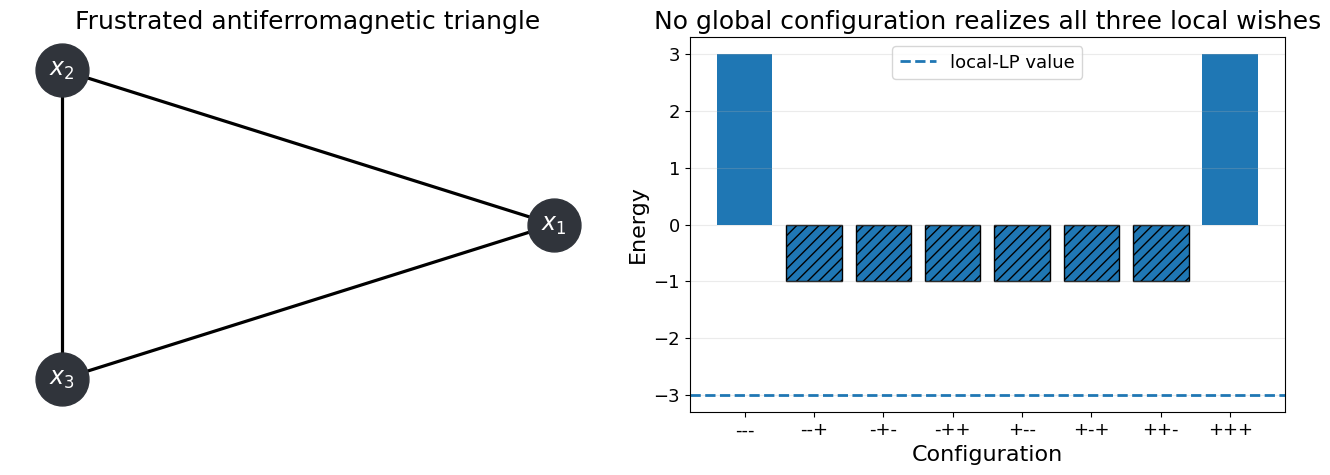

In [3]:
graph = nx.Graph(EDGES)
pos = nx.circular_layout(graph)
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
nx.draw_networkx_nodes(graph, pos, node_size=1450, node_color=NODE_COLOR, ax=axes[0])
nx.draw_networkx_labels(graph, pos, labels={i: rf"$x_{i+1}$" for i in range(3)},
                        font_size=17, font_color=NODE_TEXT_COLOR, ax=axes[0])
nx.draw_networkx_edges(graph, pos, width=2.3, ax=axes[0])
axes[0].set_title("Frustrated antiferromagnetic triangle")
axes[0].axis("off")

labels = ["".join("+" if value == 1 else "-" for value in state) for state in STATES]
bars = axes[1].bar(labels, ENERGIES)
for bar, energy in zip(bars, ENERGIES):
    if energy == exact_map_energy:
        bar.set_hatch("///")
        bar.set_edgecolor("black")
axes[1].axhline(fractional_energy, linestyle="--", linewidth=2.0, label="local-LP value")
axes[1].set_xlabel("Configuration")
axes[1].set_ylabel("Energy")
axes[1].set_title("No global configuration realizes all three local wishes")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch06_05_map_lp_gap")
plt.show()

## The fractional edge beliefs

Saved: figs/ch06_05_fractional_beliefs.pdf


Saved: figs/ch06_05_fractional_beliefs.png


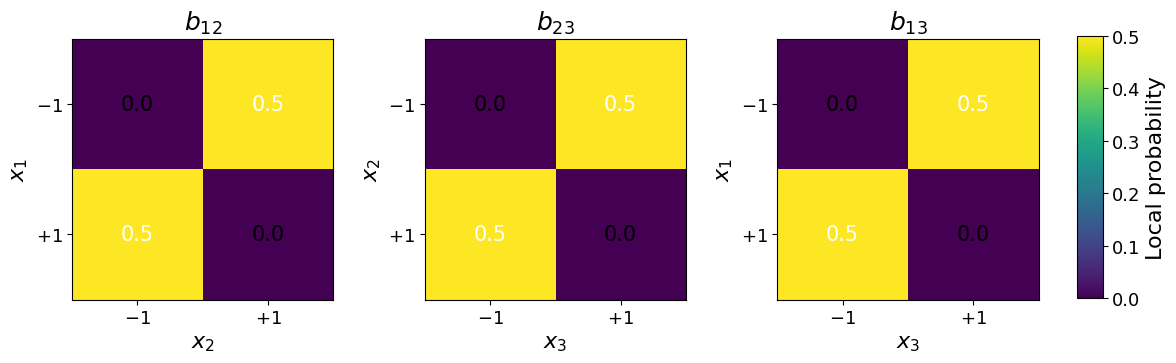

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.1))
for ax, (i, j) in zip(axes, EDGES):
    image = ax.imshow(edge_belief, vmin=0, vmax=0.5)
    ax.set_xticks([0, 1], [r"$-1$", r"$+1$"])
    ax.set_yticks([0, 1], [r"$-1$", r"$+1$"])
    ax.set_xlabel(rf"$x_{j+1}$")
    ax.set_ylabel(rf"$x_{i+1}$")
    ax.set_title(rf"$b_{{{i+1}{j+1}}}$")
    for a in range(2):
        for b in range(2):
            value = edge_belief[a, b]
            ax.text(b, a, f"{value:.1f}", ha="center", va="center",
                    color="white" if value > 0.25 else "black", fontsize=15)
fig.subplots_adjust(right=0.88, wspace=0.35)
cax = fig.add_axes([0.91, 0.18, 0.02, 0.64])
fig.colorbar(image, cax=cax, label="Local probability")
save_figure(fig, "ch06_05_fractional_beliefs")
plt.show()

## The soft minimum approaches MAP

Saved: figs/ch06_05_zero_temperature.pdf


Saved: figs/ch06_05_zero_temperature.png


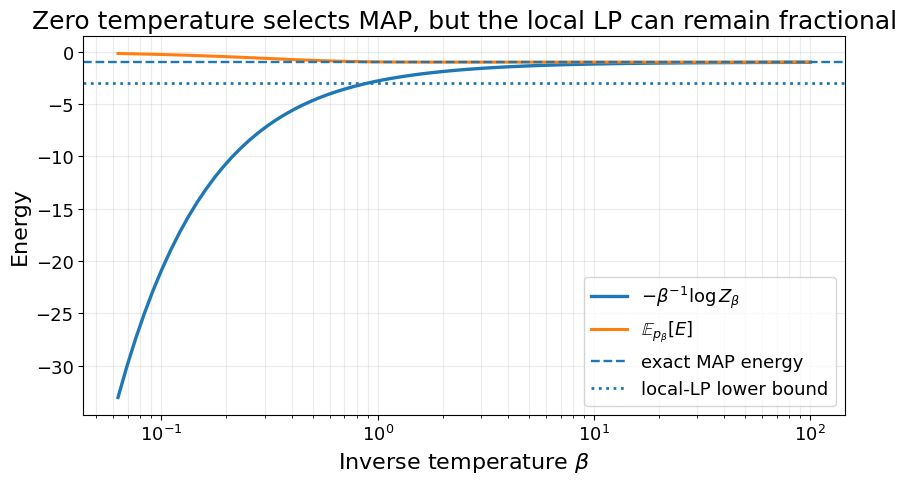

In [5]:
beta_grid = np.logspace(-1.2, 2.0, 80)
free_energy = []
expected_energy = []
for beta in beta_grid:
    weights = np.exp(-beta * (ENERGIES - ENERGIES.min()))
    p = weights / weights.sum()
    log_z = -beta * ENERGIES.min() + np.log(weights.sum())
    free_energy.append(-log_z / beta)
    expected_energy.append(np.dot(p, ENERGIES))

fig, ax = plt.subplots(figsize=(8.8, 5.1))
ax.semilogx(beta_grid, free_energy, linewidth=2.4, label=r"$-\beta^{-1}\log Z_\beta$")
ax.semilogx(beta_grid, expected_energy, linewidth=2.2, label=r"$\mathbb{E}_{p_\beta}[E]$")
ax.axhline(exact_map_energy, linestyle="--", linewidth=1.7, label="exact MAP energy")
ax.axhline(fractional_energy, linestyle=":", linewidth=2.0, label="local-LP lower bound")
ax.set_xlabel(r"Inverse temperature $\beta$")
ax.set_ylabel("Energy")
ax.set_title("Zero temperature selects MAP, but the local LP can remain fractional")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch06_05_zero_temperature")
plt.show()

## Exercises

1. **Basic.** Verify all local normalization and marginal-consistency constraints for the fractional beliefs.
2. **Extension.** Remove one edge from the triangle.  Show that the local polytope becomes exact.
3. **Modeling.** Add a fourth spin and compare odd and even cycles.
4. **Research.** Add cycle inequalities to the LP and determine the smallest family sufficient to close the gap in this example.